In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from arch import arch_model
import warnings
import joblib
import os
warnings.filterwarnings("ignore")

In [4]:
prices  = pd.read_csv("../data/jse_prices.csv", index_col=0, parse_dates=True)
returns = np.log(prices / prices.shift(1)).dropna()



In [5]:
# return 
ret_pct = returns * 100
ret_pct.head()

,Naspers,MTN Group,Standard Bank,Anglo American,Shoprite
Date,,,,,
2019-01-03,0.198409,-0.703643,0.143538,1.620908,1.311261
2019-01-04,0.631547,1.036411,2.286325,1.241571,1.608607
2019-01-07,0.598729,0.228876,-1.117132,-0.956267,0.292108
2019-01-08,0.563242,-1.138016,0.483625,0.545952,-0.921744
2019-01-09,2.521026,0.863295,4.735998,0.449010,1.408500


In [7]:
# We'll store results here
garch_results  = {}   # fitted model objects
garch_params   = {}   # omega, alpha, beta
cond_vol       = {}   # conditional volatility series

for stock in ret_pct.columns:

    series = ret_pct[stock].dropna()

    # Build model: constant mean + GARCH(1,1) with Student-t errors
    model = arch_model(
        series,
        mean="Constant",
        vol="Garch",
        p=1, q=1,
        dist="t"          # t-dist handles fat tails better than normal
    )

    result = model.fit(disp="off")   # disp="off" silences iteration log

    # Extract key parameters
    params = result.params
    garch_results[stock] = result
    garch_params[stock]  = {
        "omega": params["omega"],
        "alpha[1]": params["alpha[1]"],
        "beta[1]":  params["beta[1]"],
        "nu (df)":  params["nu"],
        "persistence": params["alpha[1]"] + params["beta[1]"]
    }

    cond_vol[stock] = result.conditional_volatility

    print(result.summary().tables[1])

                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0794  5.188e-02      1.531      0.126 [-2.226e-02,  0.181]
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu            -0.0334  4.756e-02     -0.702      0.483 [ -0.127,5.984e-02]
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0555  5.114e-02      1.085      0.278 [-4.473e-02,  0.156]
                                 Mean Model                                
                

In [20]:
#  Create a DataFrame from the parameters for easier comparison.
garch_params_df = pd.DataFrame(garch_params).T.round(4)
garch_params_df.sort_values("persistence", ascending=False)

garch_params_df.to_csv("../data/garch_parameters.csv")
print("Saved GARCH parameters to garch_parameters.csv")

Saved GARCH parameters to garch_parameters.csv


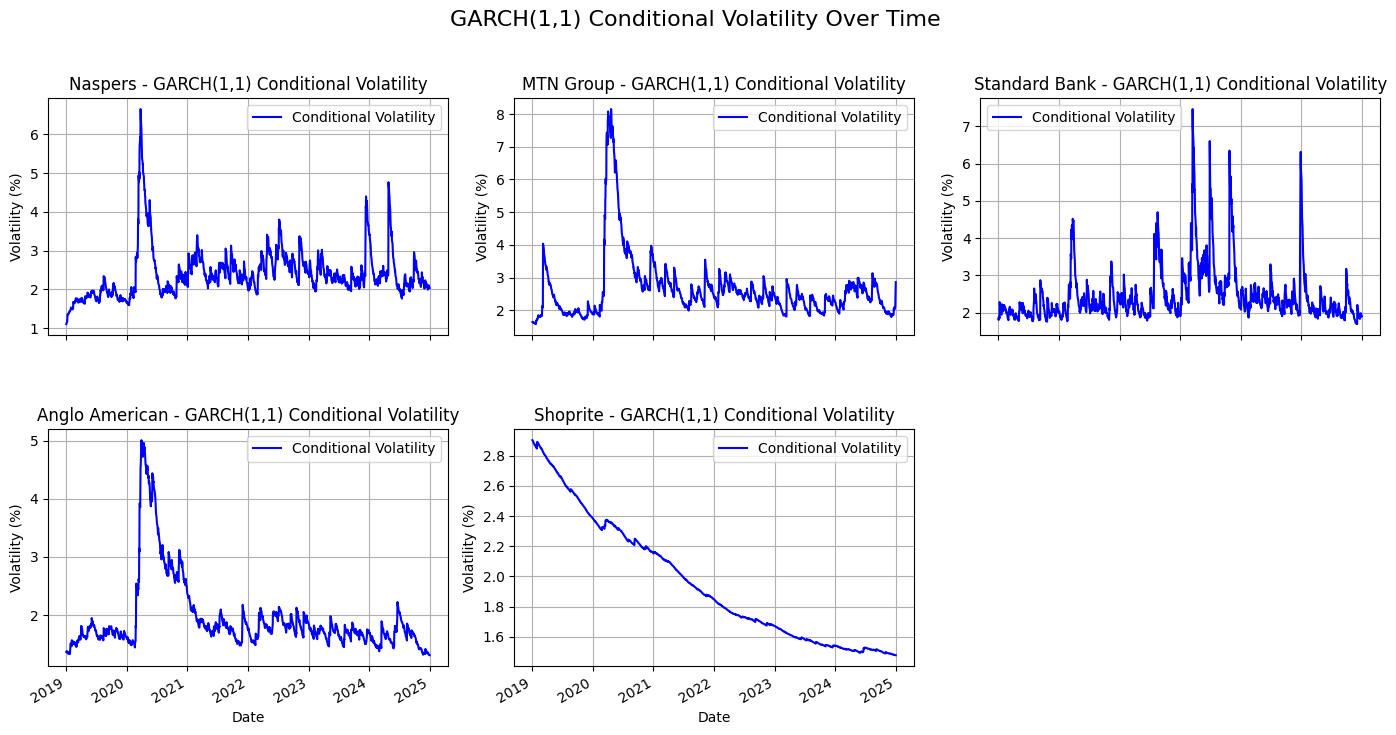

In [15]:
# The plot helps identify volatility clustering, high/low risk regimes,
# and how long shocks persist after major events.

# conditional volatility plots
plt.figure(figsize=(14, 8))
for i, stock in enumerate(ret_pct.columns):
    plt.subplot(2, 3, i+1)
    plt.plot(cond_vol[stock], label="Conditional Volatility", color="blue")
    plt.title(f"{stock} - GARCH(1,1) Conditional Volatility")
    plt.xlabel("Date")
    plt.ylabel("Volatility (%)")
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gcf().autofmt_xdate()  # Rotate date labels for better readability
    plt.subplots_adjust(hspace=0.4)  # Adjust vertical spacing between subplots
    plt.suptitle("GARCH(1,1) Conditional Volatility Over Time", fontsize=16, y=1.02)\
    
plt.savefig("../outputs/04_garch_conditional_volatility.png", bbox_inches="tight")
plt.show()




In [18]:
os.makedirs("../models", exist_ok=True)

# Save each fitted GARCH model
for stock, result in garch_results.items():
    filename = stock.lower().replace(" ", "_")
    joblib.dump(result, f"../models/garch_{filename}.pkl")
    print(f"✅ Saved garch_{filename}.pkl")

print("\n All models saved to /models folder")

✅ Saved garch_naspers.pkl
✅ Saved garch_mtn_group.pkl
✅ Saved garch_standard_bank.pkl
✅ Saved garch_anglo_american.pkl
✅ Saved garch_shoprite.pkl

 All models saved to /models folder
